<a href="https://colab.research.google.com/github/calvinpan1/ds3001_assignments/blob/main/Project_3_Demand_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis



In [4]:
# Load dataset
import pandas as pd

url = "https://raw.githubusercontent.com/ds4e/undergrad_ml_assignments/main/demand_est_project/air_fryers_clean_brand_year.csv"

airfryers = pd.read_csv(url)

# Save into current working directory
airfryers.to_csv("air_fryers_clean_brand_year.csv", index=False)

# Check
airfryers.head(10)

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364
5,air_fryers,2019,instant_pot,238,13,78.019945,4.364286,0.542017,0.0,0.550420,0.000000,0.000000,15076,0.015787,-4.148589
6,air_fryers,2019,ninja,2904,18,112.158374,4.778650,0.994490,0.0,0.000000,0.000000,0.000000,15076,0.192624,-1.647015
7,air_fryers,2019,nuwave,484,15,151.099937,4.321901,0.993802,0.0,0.561983,0.111570,0.000000,15076,0.032104,-3.438774
8,air_fryers,2019,oster,506,5,191.943688,4.380830,1.000000,0.0,0.772727,0.000000,0.000000,15076,0.033563,-3.394323
9,air_fryers,2019,ultrean,755,4,80.624675,4.618013,1.000000,0.0,0.835762,0.000000,0.000000,15076,0.050080,-2.994142


1.

In [5]:
# Verify the number of brands
print("Number of brands:", airfryers["brand"].nunique())

# Verify years
print("Years:", sorted(airfryers["year"].unique()))

Number of brands: 10
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


2.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

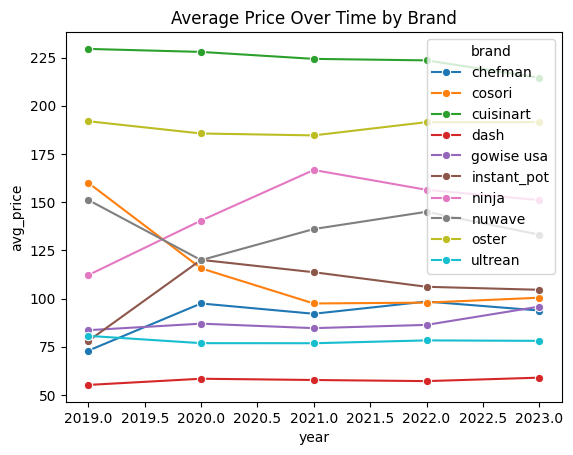

In [7]:
# Average price over time
plt.figure()
sns.lineplot(data=airfryers, x="year", y="avg_price", hue="brand", marker="o")
plt.title("Average Price Over Time by Brand")
plt.show()

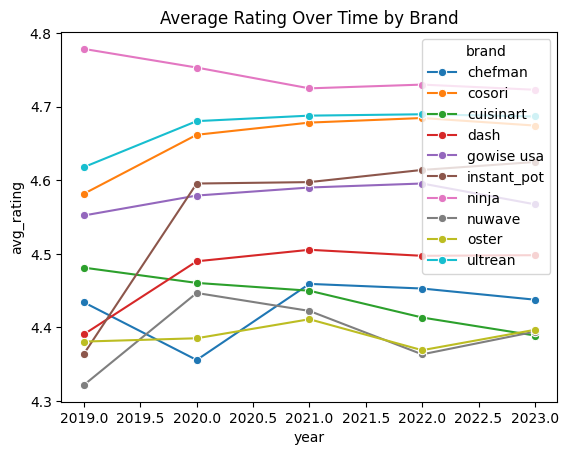

In [8]:
# Average rating over time
plt.figure()
sns.lineplot(data=airfryers, x="year", y="avg_rating", hue="brand", marker="o")
plt.title("Average Rating Over Time by Brand")
plt.show()

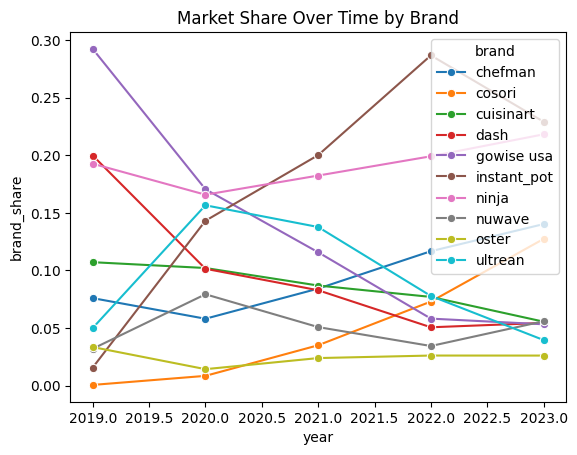

In [9]:
# Brand market share over time
plt.figure()
sns.lineplot(data=airfryers, x="year", y="brand_share", hue="brand", marker="o")
plt.title("Market Share Over Time by Brand")
plt.show()

3.

In [10]:
# Average feature shares
features = [
    "compact_share", "dual_basket_share", "oven_style_share",
    "rotisserie_share", "window_share"
]

airfryers[features].mean().sort_values(ascending=False)

,0
compact_share,0.980081
oven_style_share,0.562647
rotisserie_share,0.070762
window_share,0.036741
dual_basket_share,0.002260


The most common feature is compact design with an average share of about 98%. Oven-style models are also common with a share of about 56%.

There are several features that are rare. Specifically, rotisserie appears in only about 7% of products while window features are even less common at about 4%. The rarest feature is dual-basket design with a share of about 0.2%, indicating it is almost nonexistent in this market.

In [11]:
# By brand
airfryers.groupby("brand")[features].mean()

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


There is evidence that some brands specialize in different product features. For example, Chefman offers a wider range of features with relatively high shares of rotisserie (about 37%) and window (about 36%) models. This suggests a focus on more feature heavy or premium designs. Gowise USA also shows some specialization in rotisserie models (about 18%), which is uncommon among other brands.

Other brands like Cuisinart, Dash, Oster, and Ultrean specialize in oven-style air fryers with very high oven-style shares (80% and above), indicating a focus on that specific product type.

Brands such as Cosori and Ninja are more concentrated in compact designs with very low shares of additional features. This suggests a more standardized product lineup.

4.

The market appears to be segmented by price but relatively stable over time. Cuisinart is consistently the most expensive brand with Ninja and Oster also positioned in the higher price range. Brands such as Dash, Ultrean, and Gowise USA occupy the low price segment. In terms of market share, Instant Pot grows to become the dominant brand, holding the largest share in later years. Additionally, Ninja maintains a relatively strong position. The majority of other brands have smaller or declining shares. Overall, the market looks fairly stable. Specifically, prices and ratings change only slightly over time. While there are some gradual shifts in market share (ex: the rise of Instant Pot and decline of Gowise USA), there are no sudden disruptions. This suggests a sophisticated and competitive market of airfryers.

## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Estimate the model:

# Set y
y = airfryers["log_brand_share"]

# Get dummies
brand_dummies = pd.get_dummies(airfryers["brand"],
                               prefix="brand", drop_first=True, dtype=int)
year_dummies = pd.get_dummies(airfryers["year"].astype(str),
                              prefix="year", drop_first=True, dtype=int)
# Set feature cols
feature_cols = airfryers[["compact_share", "dual_basket_share", "rotisserie_share", "window_share"]]

X = pd.concat(
    [airfryers[["avg_price", "avg_rating"]], feature_cols,
    brand_dummies,
    year_dummies],
    axis=1,)

model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_})

print("R-squared:", r2)
coef_table

R-squared: 0.7498869716880936


,feature,coefficient
0,avg_price,-0.038422
1,avg_rating,-0.917481
2,compact_share,10.651121
3,dual_basket_share,10.948041
4,rotisserie_share,-4.051675
5,window_share,8.386133
6,brand_cosori,0.919923
7,brand_cuisinart,6.365779
8,brand_dash,-0.007967
9,brand_gowise usa,2.234496



Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?

$\hat{\beta}_{price}$ is -0.0384.

2. Is it negative? Why is that important?

$\hat{\beta}_{price}$ is negative, which is important because it means that there is an inverse relationship between price and product share. As price increases, product share decreases, which is exactly what the law of demand says.

3. Which product features are associated with higher demand?

Being compact, having a dual basket, and having a transparent window are associated with higher demand.

4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.

Cuisinart (6.36), Ninja (4.46), Instant Pot (4.12), and Oster (3.68) have the largest coefficients relative to the dropped brand of Chefman. This suggests that more luxury brand names (Cuisinart, Ninja, and Oster) and known brand names (Instant Pot, Cuisinart) tend to have a more positive impact on demand, which is exactly what we'd expect.

5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.

2020, 2021, and 2023 all have coefficients ranging from 0.11-0.12 relative to the dropped year of 2019, while 2022 had a negative coefficient of -0.04. This could be due to general consumer spending trends: 2020-2021 were strong due to COVID consumer spending increases (stimulus checks, increased consumption due to having less to do at home, more pandemic-era interest in cooking), 2022 was weaker due to a general spike in inflation and less consumer confidence, and 2023 saw this inflation spike go down.

6. What is the model's $R^2$?

The model's R^2 is 0.749, suggesting that around 3/4ths of the variation in demand is explained by the model. This model is relatively strong.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

## 4. Results

Submit a GitHub repo containing:

1. A notebook corresponding to the data analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
2. A notebook corresponding to the data scientist work, including the code and graphs, explicitly answering the questions above in text markdown chunks
3. A notebook corresponding to the pricing analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
4. A short presentation of your findings, about 5-8 slides.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model (multinomial logistic regression, estimated by linear regression on log market share)
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion about the brands' relative positions in the market

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.